In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from imblearn.over_sampling import SMOTE

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [5]:
df = pd.read_csv("../data/creditcard.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

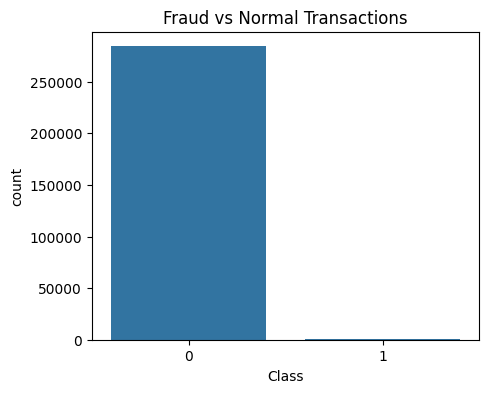

In [7]:
plt.figure(figsize=(5,4))
sns.countplot(x='Class', data=df)
plt.title("Fraud vs Normal Transactions")
plt.savefig("../images/fraud_vs_normal.png", bbox_inches='tight')
plt.show()

In [8]:
scaler = StandardScaler()

df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

In [9]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape:", X_test.shape)

Train Shape: (227845, 30)
Test Shape: (56962, 30)


In [10]:
models = {

    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB(),

    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss'),

    "LightGBM": LGBMClassifier()
}

In [11]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_res.value_counts())

Before SMOTE:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE:
Class
0    227451
1    227451
Name: count, dtype: int64


In [12]:
results = []

for name, model in models.items():

    print("Training:", name)

    model.fit(X_train_res, y_train_res)

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    results.append([name, acc, f1, roc])

Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: KNN
Training: Naive Bayes
Training: XGBoost
Training: LightGBM
[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.027254 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


In [13]:
results_df = pd.DataFrame(results, columns=["Model","Accuracy","F1 Score","ROC-AUC"])

results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,F1 Score,ROC-AUC
2,Random Forest,0.999421,0.829016,0.967850
5,XGBoost,0.999245,0.801843,0.979159
6,LightGBM,0.998227,0.624535,0.957376
3,KNN,0.998051,0.607774,0.953588
1,Decision Tree,0.997261,0.490196,0.881484
0,Logistic Regression,0.974264,0.109356,0.969848
4,Naive Bayes,0.973842,0.103490,0.964414


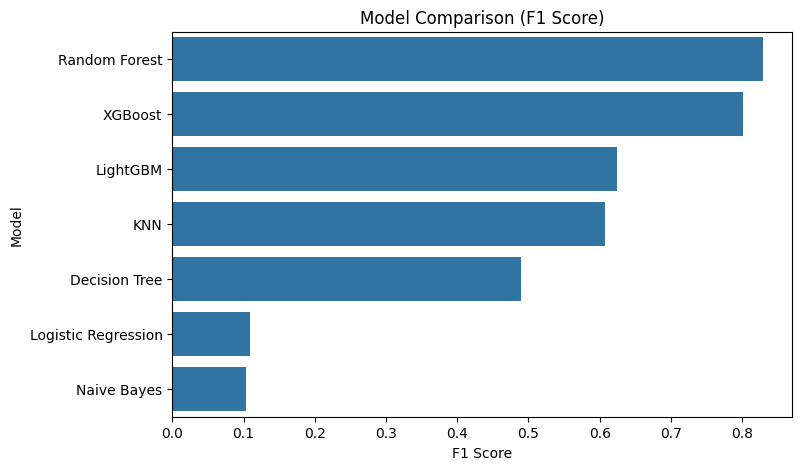

In [14]:
plt.figure(figsize=(8,5))

sns.barplot(x="F1 Score", y="Model", data=results_df.sort_values("F1 Score", ascending=False))

plt.title("Model Comparison (F1 Score)")
plt.savefig("../images/model_comparison.png", bbox_inches='tight')
plt.show()

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Train best model with better parameters
best_model = RandomForestClassifier(n_estimators=200, random_state=42)

best_model.fit(X_train_res, y_train_res)

# Predictions
y_pred = best_model.predict(X_test)

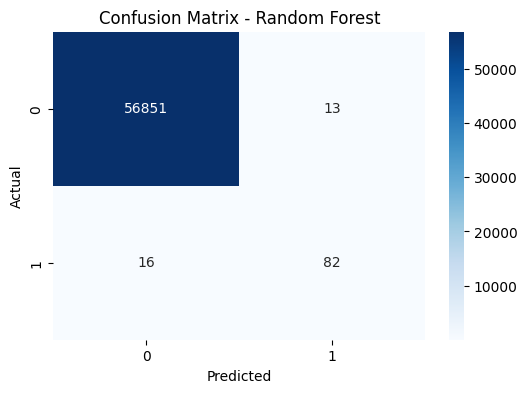

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Random Forest")
plt.savefig("../images/confusion_matrix.png", bbox_inches='tight')
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:
importance = best_model.feature_importances_

import pandas as pd

features = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

features = features.sort_values(by="Importance", ascending=False)

features.head(10)

,Feature,Importance
14,V14,0.183715
10,V10,0.111427
4,V4,0.107683
12,V12,0.096535
17,V17,0.086032
11,V11,0.062092
3,V3,0.058436
16,V16,0.053122
2,V2,0.031262
7,V7,0.023408


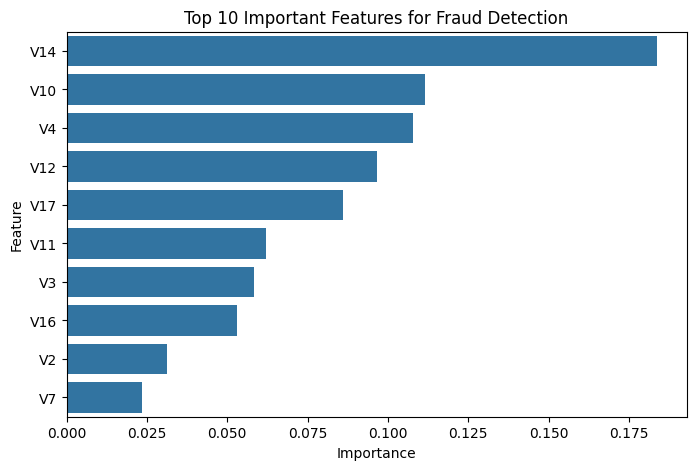

In [18]:
plt.figure(figsize=(8,5))

sns.barplot(x="Importance", y="Feature", data=features.head(10))

plt.title("Top 10 Important Features for Fraud Detection")
plt.savefig("../images/feature_importance.png", bbox_inches='tight')

plt.show()

In [20]:
import pickle

with open("../models/fraud_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("../models/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved successfully!")

Model and scaler saved successfully!


In [22]:
import pickle

pickle.dump(models["Logistic Regression"], open("../models/logistic_regression.pkl","wb"))
pickle.dump(models["Decision Tree"], open("../models/decision_tree.pkl","wb"))
pickle.dump(models["Random Forest"], open("../models/random_forest.pkl","wb"))
pickle.dump(models["XGBoost"], open("../models/xgboost.pkl","wb"))
pickle.dump(models["KNN"], open("../models/knn.pkl","wb"))
pickle.dump(models["Naive Bayes"], open("../models/naive_bayes.pkl","wb"))